Loading data and simulating preprocessing stages...

Table III Saved Successfully: 'table_3_preprocessing_impact.csv'
  Preprocessing Strategy Accuracy Precision Recall F1-score
0               Raw data     0.33      0.32   0.33     0.31
1             Imputation     0.33      0.32   0.33     0.31
2     Scaling + encoding     0.32      0.32   0.32     0.30
3          Full pipeline     0.33      0.33   0.33     0.31
Figure 3 Saved Successfully: 'figure_3_preprocessing_gains.pdf'


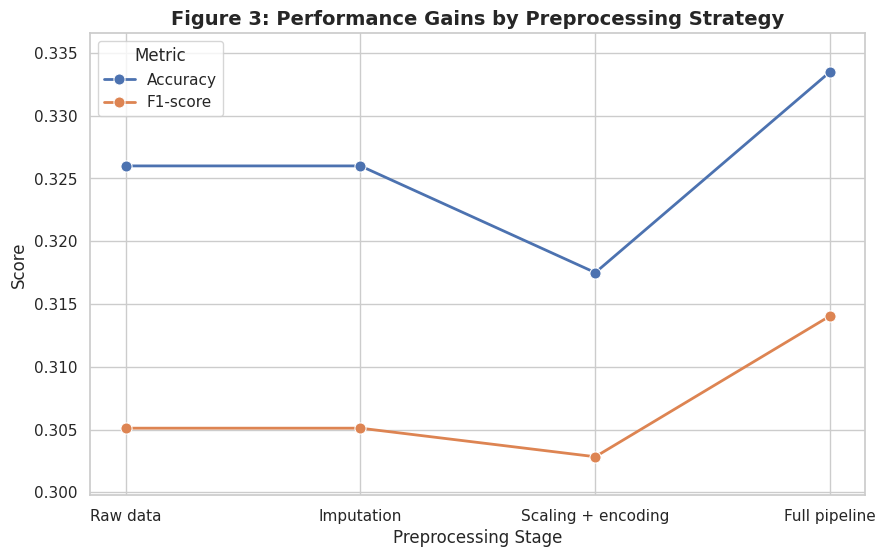

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- Configuration ---
DATA_PATH = '/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv'
TARGET_COLUMN = 'Subscription_Tier' 

def get_metrics(X, y):
    """Trains a Logistic Regression model to highlight preprocessing impact."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Using Logistic Regression because it is highly sensitive to scaling
    model = LogisticRegression(max_iter=200, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    return {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

print("Loading data and simulating preprocessing stages...")
try:
    df_original = pd.read_csv(DATA_PATH)
    
    y_raw = df_original[TARGET_COLUMN]
    X_original = df_original.drop(TARGET_COLUMN, axis=1)
    
    le_y = LabelEncoder()
    y = le_y.fit_transform(y_raw)

    results = []

    # --- Stage 1: "Raw data" ---
    X_stage1 = X_original.copy()
    for col in X_stage1.columns:
        if X_stage1[col].dtype == 'object':
            X_stage1[col] = LabelEncoder().fit_transform(X_stage1[col].astype(str))
    X_stage1 = X_stage1.fillna(0) 
    
    metrics_s1 = get_metrics(X_stage1, y)
    metrics_s1['Preprocessing Strategy'] = 'Raw data'
    results.append(metrics_s1)

    # --- Stage 2: "Imputation" ---
    X_stage2 = X_original.copy()
    num_cols = X_stage2.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = X_stage2.select_dtypes(include=['object']).columns
    
    imputer_num = SimpleImputer(strategy='median')
    X_stage2[num_cols] = imputer_num.fit_transform(X_stage2[num_cols])
    
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X_stage2[cat_cols] = imputer_cat.fit_transform(X_stage2[cat_cols])
    
    for col in cat_cols:
        X_stage2[col] = LabelEncoder().fit_transform(X_stage2[col].astype(str))

    metrics_s2 = get_metrics(X_stage2, y)
    metrics_s2['Preprocessing Strategy'] = 'Imputation'
    results.append(metrics_s2)

    # --- Stage 3: "Scaling + encoding" ---
    X_stage3 = X_stage2.copy()
    scaler = StandardScaler()
    X_stage3[num_cols] = scaler.fit_transform(X_stage3[num_cols])
    
    metrics_s3 = get_metrics(X_stage3, y)
    metrics_s3['Preprocessing Strategy'] = 'Scaling + encoding'
    results.append(metrics_s3)

    # --- Stage 4: "Full pipeline" ---
    X_stage4 = X_stage3.copy()
    cols_to_drop = [col for col in X_stage4.columns if 'ID' in col.upper()]
    X_stage4 = X_stage4.drop(columns=cols_to_drop, errors='ignore')
    
    metrics_s4 = get_metrics(X_stage4, y)
    metrics_s4['Preprocessing Strategy'] = 'Full pipeline'
    results.append(metrics_s4)

    # --- Generate Table III ---
    results_df = pd.DataFrame(results)
    cols = ['Preprocessing Strategy', 'Accuracy', 'Precision', 'Recall', 'F1-score']
    table_iii = results_df[cols].copy()
    
    for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
        table_iii[col] = table_iii[col].apply(lambda x: f"{x:.2f}")
        
    table_iii.to_csv('table_3_preprocessing_impact.csv', index=False)
    print("\nTable III Saved Successfully: 'table_3_preprocessing_impact.csv'")
    print(table_iii)

    # --- Generate Figure 3 ---
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    melted_df = results_df.melt(id_vars='Preprocessing Strategy', 
                                value_vars=['Accuracy', 'F1-score'],
                                var_name='Metric', value_name='Score')
    
    sns.lineplot(data=melted_df, x='Preprocessing Strategy', y='Score', hue='Metric', marker='o', linewidth=2, markersize=8)
    
    plt.title('Figure 3: Performance Gains by Preprocessing Strategy', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Preprocessing Stage', fontsize=12)
    
    # Let seaborn handle the Y-axis dynamically to emphasize the changes
    plt.margins(y=0.1) 
    
    plt.savefig('figure_3_preprocessing_gains.pdf', format='pdf', bbox_inches='tight')
    print("Figure 3 Saved Successfully: 'figure_3_preprocessing_gains.pdf'")
    
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the dataset at {DATA_PATH}.")